<a href="https://colab.research.google.com/github/ch-praneeth-08/DSA/blob/main/Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=206edd4d6a4707fb986e2fb3b730e18b24fa8709a6df9a20ce981fa40c403d1b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
import lime
import lime.lime_tabular
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    ShuffleSplit
)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score


In [3]:
# Load dataset from Kaggle
# Download latest version
dataset_path = kagglehub.dataset_download("laotse/credit-risk-dataset")

# Print the path where files are stored
print("Dataset downloaded to:", dataset_path)

100%|██████████| 368k/368k [00:00<00:00, 726kB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1


In [4]:
# Find the CSV file in the downloaded directory
csv_file = [f for f in os.listdir(dataset_path) if f.endswith(".csv")][0]

# Load the dataset
df = pd.read_csv(os.path.join(dataset_path, csv_file))

# Display the first few rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Loan Application Dataset Documentation

## 1. Applicant Information

### **person_age**
- **Description**: Age of the individual applying for the loan.

### **person_income**
- **Description**: Annual income of the individual.

### **person_home_ownership**
- **Description**: Type of home ownership of the individual.
- **Categories**:
  - **rent**: The individual is currently renting a property.
  - **mortgage**: The individual has a mortgage on the property they own.
  - **own**: The individual owns their home outright.
  - **other**: Other categories of home ownership that may be specific to the dataset.

### **person_emp_length**
- **Description**: Employment length of the individual in years.

---

## 2. Loan Information

### **loan_intent**
- **Description**: The intent behind the loan application.

### **loan_grade**
- **Description**: The grade assigned to the loan based on the creditworthiness of the borrower.
- **Grades**:
  - **A**: The borrower has a high creditworthiness, indicating low risk.
  - **B**: The borrower is relatively low-risk, but not as creditworthy as Grade A.
  - **C**: The borrower's creditworthiness is moderate.
  - **D**: The borrower is considered to have higher risk compared to previous grades.
  - **E**: The borrower's creditworthiness is lower, indicating a higher risk.
  - **F**: The borrower poses a significant credit risk.
  - **G**: The borrower's creditworthiness is the lowest, signifying the highest risk.

### **loan_amnt**
- **Description**: The loan amount requested by the individual.

### **loan_int_rate**
- **Description**: The interest rate associated with the loan.

### **loan_status**
- **Description**: Loan status, where **0 indicates non-default** and **1 indicates default**.
- **Values**:
  - **0 (Non-default)**: The borrower successfully repaid the loan as agreed, and there was no default.
  - **1 (Default)**: The borrower failed to repay the loan according to the agreed-upon terms and defaulted on the loan.

### **loan_percent_income**
- **Description**: The percentage of income represented by the loan amount.

---

## 3. Credit History

### **cb_person_default_on_file**
- **Description**: Historical default of the individual as per credit bureau records.
- **Values**:
  - **Y**: The individual has a history of defaults on their credit file.
  - **N**: The individual does not have any history of defaults.

### **cb_preson_cred_hist_length**
- **Description**: The length of credit history for the individual.


In [5]:
# Checking data types
print(df.dtypes)

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


In [6]:
# Checking statistics
print(df.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

In [7]:
#Checking unique values
df.nunique()

,0
person_age,58
person_income,4295
person_home_ownership,4
person_emp_length,36
loan_intent,6
loan_grade,7
loan_amnt,753
loan_int_rate,348
loan_status,2
loan_percent_income,77


In [8]:
# Checking missing values
print(df.isnull().sum().sort_values(ascending=False)[:10])

loan_int_rate            3116
person_emp_length         895
person_income               0
person_age                  0
person_home_ownership       0
loan_intent                 0
loan_grade                  0
loan_amnt                   0
loan_status                 0
loan_percent_income         0
dtype: int64


In [9]:
# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include=[object]).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_8726/3715220776.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_8726/3715220776.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [10]:
# Checking missing values
print(df.isnull().sum().sort_values(ascending=False)[:10])

person_age               0
person_income            0
person_home_ownership    0
person_emp_length        0
loan_intent              0
loan_grade               0
loan_amnt                0
loan_int_rate            0
loan_status              0
loan_percent_income      0
dtype: int64


In [11]:
#Removing outliers

# Drop rows where person_age > 80
df = df.drop(df[df['person_age'] > 80].index, axis=0)

# Drop rows where person_emp_length > 60
df = df.drop(df[df['person_emp_length'] > 60].index, axis=0)


In [12]:
#Check statistics again
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32572.000000,3.257200e+04,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000
mean,27.714663,6.587888e+04,4.760776,9588.100209,11.009578,0.218194,0.170200,5.802898
std,6.186444,5.253279e+04,3.981220,6320.420066,3.081697,0.413026,0.106756,4.051041
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,80.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#### Feature Engineering

In [13]:
# new feature: ability to pay - loan_to_income_ratio
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']


In [14]:
# new feature: ability to pay based on employment years - loan_to_emp_length_ratio
df['loan_to_emp_length_ratio'] = df['person_emp_length'] / df['loan_amnt']


In [15]:
# new feature: ability to pay based on interest - int_rate_to_loan_amt_ratio
df['int_rate_to_loan_amt_ratio'] = df['loan_int_rate'] / df['loan_amnt']


In [16]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,0.005000,0.011140
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,0.000182,0.002340
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,0.000114,0.000435
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,0.000229,0.000408
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,0.000800,0.002856


In [17]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
count,32572.000000,3.257200e+04,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000,32572.000000
mean,27.714663,6.587888e+04,4.760776,9588.100209,11.009578,0.218194,0.170200,5.802898,0.170550,0.000773,0.001883
std,6.186444,5.253279e+04,3.981220,6320.420066,3.081697,0.413026,0.106756,4.051041,0.107023,0.001075,0.001875
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000789,0.000000,0.000200
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000,0.089693,0.000200,0.000800
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,0.148148,0.000467,0.001286
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000,0.229167,0.000952,0.002198
max,80.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,0.830000,0.021000,0.022820


In [18]:
#Categorical encodingrom sklearn.preprocessing import LabelEncoder

#  categorical columns
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

#  Label Encoding
lenc = LabelEncoder()
for col in cat_cols:
    df[col] = lenc.fit_transform(df[col])


In [19]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,loan_to_emp_length_ratio,int_rate_to_loan_amt_ratio
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2,0.104167,0.005000,0.011140
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3,0.572917,0.000182,0.002340
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2,0.534351,0.000114,0.000435
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4,0.643382,0.000229,0.000408
5,21,9900,2,2.0,5,0,2500,7.14,1,0.25,0,2,0.252525,0.000800,0.002856


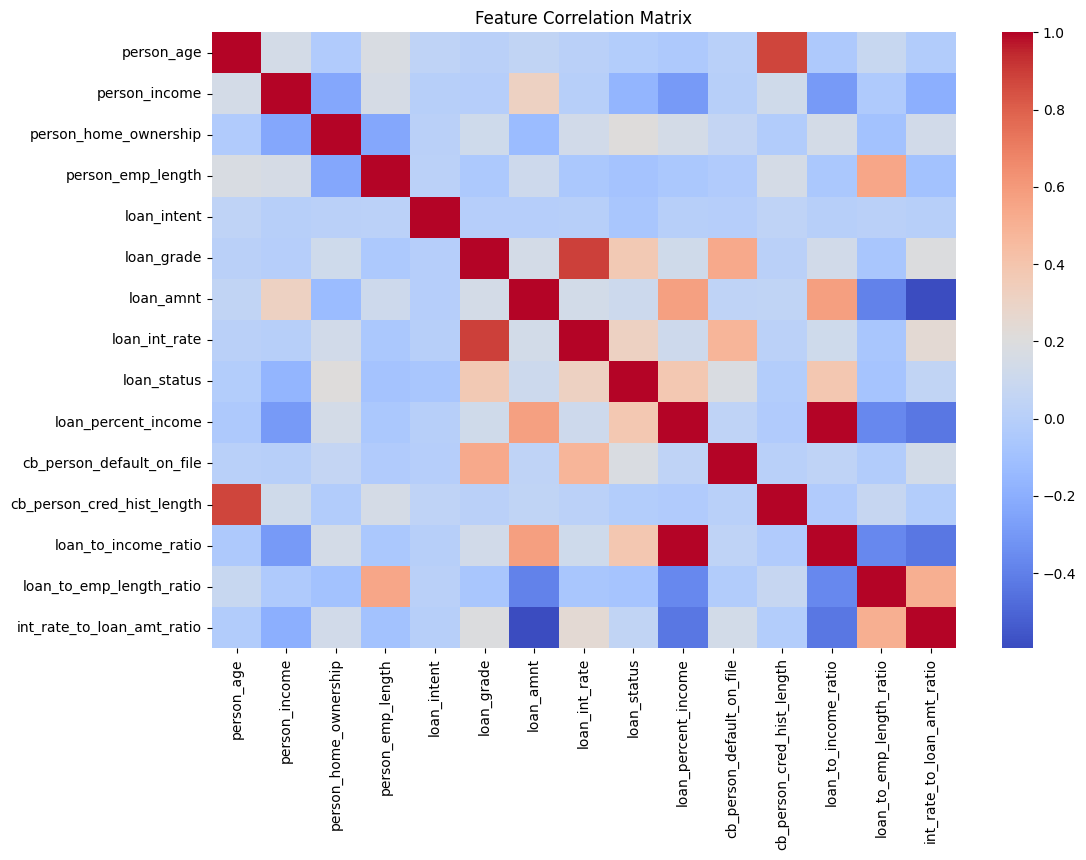

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()


In [21]:
#Checking class imbalance
df.loan_status.value_counts() #high class imbalance found

,count
loan_status,
0,25465
1,7107


In [22]:
#SMOTE for data oversampling for loan statuis = 1

In [23]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['loan_status'])  # Features
y = df['loan_status']  # Target

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class distribution after SMOTE:\n", pd.Series(y_resampled).value_counts())


Class distribution after SMOTE:
 loan_status
0    25465
1    25465
Name: count, dtype: int64


In [24]:


def k_fold_validation(model, X, y, k=5):
    """
    Perform K-Fold Cross-Validation.

    :param model: Machine Learning model instance
    :param X: Feature set
    :param y: Target variable
    :param k: Number of folds (default: 5)
    :return: Mean cross-validation accuracy
    """
    cv_scores = cross_val_score(model, X, y, cv=k, scoring='accuracy')
    print(f"K-Fold Cross-Validation Mean Accuracy: {np.mean(cv_scores):.4f}")
    return np.mean(cv_scores)


def stratified_k_fold_validation(model, X, y, k=5):
    """
    Perform Stratified K-Fold Validation.

    :param model: Machine Learning model instance
    :param X: Feature set
    :param y: Target variable
    :param k: Number of folds (default: 5)
    :return: Mean accuracy
    """
    strat_kfold = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for train_idx, test_idx in strat_kfold.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_train, y_train)
        scores.append(model.score(X_test, y_test))

    mean_score = np.mean(scores)
    print(f"Stratified K-Fold Mean Accuracy: {mean_score:.4f}")
    return mean_score


def monte_carlo_validation(model, X, y, n_splits=10):
    """
    Perform Monte Carlo Cross-Validation.

    :param model: Machine Learning model instance
    :param X: Feature set
    :param y: Target variable
    :param n_splits: Number of random splits (default: 10)
    :return: Mean accuracy
    """
    mc_split = ShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=mc_split)

    print(f"Monte Carlo CV Mean Accuracy: {np.mean(cv_scores):.4f}")
    return np.mean(cv_scores)


def bootstrap_validation(model, X, y, n_iterations=100):
    """
    Perform Bootstrapping to estimate model uncertainty.

    :param model: Machine Learning model instance
    :param X: Feature set
    :param y: Target variable
    :param n_iterations: Number of bootstrap samples (default: 100)
    :return: Mean and standard deviation of accuracy
    """
    bootstrap_scores = []

    for _ in range(n_iterations):
        X_resampled, y_resampled = resample(X, y, replace=True)
        model.fit(X_resampled, y_resampled)
        bootstrap_scores.append(model.score(X_test, y_test))

    mean_acc = np.mean(bootstrap_scores)
    std_acc = np.std(bootstrap_scores)

    print(f"Bootstrap Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    return mean_acc, std_acc


def train_models(X_train, y_train):
    """
    Train multiple machine learning models.

    :param X_train: Training feature set
    :param y_train: Training target variable
    :return: Dictionary containing trained models
    """
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

    stacked_model = StackingClassifier(
        estimators=[('rf', rf_model), ('xgb', xgb_model)],
        final_estimator=LogisticRegression()
    )

    models = {
        "Random Forest": rf_model,
        "XGBoost": xgb_model,
        "Stacked Model": stacked_model
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        print(f"{name} trained successfully.")

    return models


def test_models(models, X_test, y_test):
    """
    Evaluate trained models on the test set.

    :param models: Dictionary containing trained models
    :param X_test: Test feature set
    :param y_test: Test target variable
    """
    for name, model in models.items():
        accuracy = model.score(X_test, y_test)
        print(f"{name} Accuracy: {accuracy:.4f}")


def shap_explainability(model, X_test, filename="shap_summary.png"):
    """
    Generate and save SHAP summary plot.

    :param model: Trained model (e.g., XGBoost, Random Forest).
    :param X_test: Test dataset.
    :param filename: File path to save the plot (default: "shap_summary.png").
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)  # Generate SHAP plot
    plt.show()
    plt.savefig(filename, bbox_inches='tight')  # Save as an image



def lime_explainability(model, X_train, X_test,  instance_index=0, filename="lime_explanation.html"):
    """
    Generate and save LIME explanation for a single test instance.

    :param model: Trained machine learning model.
    :param X_train: Training dataset (for fitting LIME explainer).
    :param X_test: Test dataset.
    :param instance_index: Index of the test instance to explain.
    :param filename: File path to save the explanation (default: "lime_explanation.html").
    """
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=X_train.columns,
        class_names=['No Default', 'Default'],
        mode='classification'
    )

    exp = explainer.explain_instance(X_test.iloc[instance_index], model.predict_proba)
    exp.save_to_file(filename)
    exp.show_in_notebook()


def plot_validation_results(methods, accuracies,  filename="validation_plot.png"):
    """
    Save the validation accuracy comparison plot.

    :param methods: List of validation method names.
    :param accuracies: List of validation accuracy scores.
    :param filename: File path to save the plot (default: "validation_plot.png").
    """
    plt.figure(figsize=(10, 5))
    plt.bar(methods, accuracies, color='teal')
    plt.xlabel("Validation Method")
    plt.ylabel("Accuracy")
    plt.title("Comparison of Model Validation Methods")
    plt.xticks(rotation=45)
    plt.savefig(filename)  # Save plot as an image
    plt.show()


In [25]:

# Preprocessing (Assuming SMOTE has been applied)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)




In [26]:
# Initialize Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")




In [ ]:
# Run Validation Tests
k_fold_accuracy = k_fold_validation(xgb_model, X_train, y_train)
strat_k_fold_accuracy = stratified_k_fold_validation(xgb_model, X_train, y_train)
monte_carlo_accuracy = monte_carlo_validation(xgb_model, X_train, y_train)
bootstrap_mean, bootstrap_std = bootstrap_validation(xgb_model, X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:40:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

K-Fold Cross-Validation Mean Accuracy: 0.9356


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Stratified K-Fold Mean Accuracy: 0.9358


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:41:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [ ]:
# Visualize Validation Results
validation_methods = ["K-Fold", "Stratified K-Fold", "Monte Carlo", "Bootstrapping"]
validation_accuracies = [
    k_fold_accuracy,
    strat_k_fold_accuracy,
    monte_carlo_accuracy,
    bootstrap_mean
]

plot_validation_results(validation_methods, validation_accuracies)

In [ ]:
# Train Models
trained_models = train_models(X_train, y_train)

# Test Models
test_models(trained_models, X_test, y_test)


In [ ]:
# Explainability
shap_explainability(trained_models["XGBoost"], X_test)

In [ ]:
lime_explainability(trained_models["XGBoost"], X_train, X_test)